# Esercizio: Wine — Classificazione Multiclasse

In questo esercizio applichiamo la pipeline di ML a un problema di **classificazione multiclasse** (3 classi), il dataset **Wine**. Rispetto alla lezione principale (classificazione binaria su Diabetes), le differenze chiave sono:

- **3 classi** invece di 2 → la Logistic Regression usa `multi_class='multinomial'` con la funzione **softmax**
- Il **pairplot** con correlazione deve gestire correttamente la colorazione a 3 colori (fix in utils_esercizi.py)
- L'MLP usa un **output layer con 3 neuroni** (uno per classe) invece di 1

Gli obiettivi didattici:
- estendere la pipeline binaria alla classificazione multiclasse
- osservare come le 3 classi si separano nello spazio delle feature chimiche

## Il Dataset Wine

Il dataset **Wine** è incluso in scikit-learn e raccoglie dati chimici da 3 **cultivar** di vino italiane:

- **178 campioni** (bottiglie analizzate)
- **13 feature continue**: analisi chimiche (alcol, acido malico, ceneri, flavonoidi, prolina, ecc.)
- **Target categorico**: 3 classi (cultivar 0, 1, 2) — nessun ordine naturale
- **Nessun valore mancante** (dataset già pulito, ben bilanciato)

Il dataset è considerato "facile" per la classificazione: le 3 classi sono ben separabili con modelli lineari. L'accuracy attesa è ~97-99%.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import load_wine
from utils_esercizi import (plot_histograms, plot_boxplots, plot_pairplot_with_correlation,
                   nestedKFolfCV, nested_cv_bias_variance, plot_complexity_curve,
                   count_mlp_params)

warnings.filterwarnings('ignore')

wine = load_wine(as_frame=True)
df   = wine.frame.copy()
target       = 'target'
features     = [c for c in df.columns if c != target]
target_names = wine.target_names   # ['class_0', 'class_1', 'class_2']
print(f"Shape: {df.shape}")
print(f"Classi: {target_names}")
print(f"Features ({len(features)}): {features}")

Shape: (178, 14)
Classi: ['class_0' 'class_1' 'class_2']
Features (13): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


---

## Exploratory Data Analysis — Analisi Univariata

Prima di qualsiasi modellazione, studiamo la distribuzione delle singole feature e il bilanciamento delle classi. Un dataset sbilanciato richiede strategie diverse (es. `class_weight='balanced'`); qui le classi sono abbastanza bilanciate.

In [12]:
print("=== Prime 3 righe ===")
print(df.head(3))
print()
print("=== Distribuzione delle classi ===")
print(df[target].value_counts().sort_index())

=== Prime 3 righe ===
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   

   od280/od315_of_diluted_wines  proline  target  
0                          3.92   1065.0       0  
1                          3.40   1050.0       0  
2                          3.17   1185.0       0  

=== Distribuzione delle classi ===
target
0    59
1    71
2    48
Name: count, dtype: int64


In [13]:
print("=== Statistiche descrittive ===")
print(df.describe().round(2))
print()
print("=== Tipi di dato ===")
print(df.dtypes)
print()
print("=== Valori NaN ===")
print(df.isnull().sum())

=== Statistiche descrittive ===
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34                  0.13 

**Osservazioni:**
- Il dataset è **pulito**: nessun NaN, tutte le feature sono numeriche continue.
- Le classi sono bilanciate: classe 0 → 59 campioni, classe 1 → 71 campioni, classe 2 → 48 campioni.
- Le feature hanno **scale molto diverse**: `proline` varia da 278 a 1680, mentre `nonflavanoid_phenols` da 0.13 a 0.66. La standardizzazione è **fondamentale**.
- Notiamo già da `describe` che alcune feature (es. `flavanoids`, `proline`) hanno distribuzioni molto diverse tra i quartili → potrebbero essere discriminanti tra le classi.

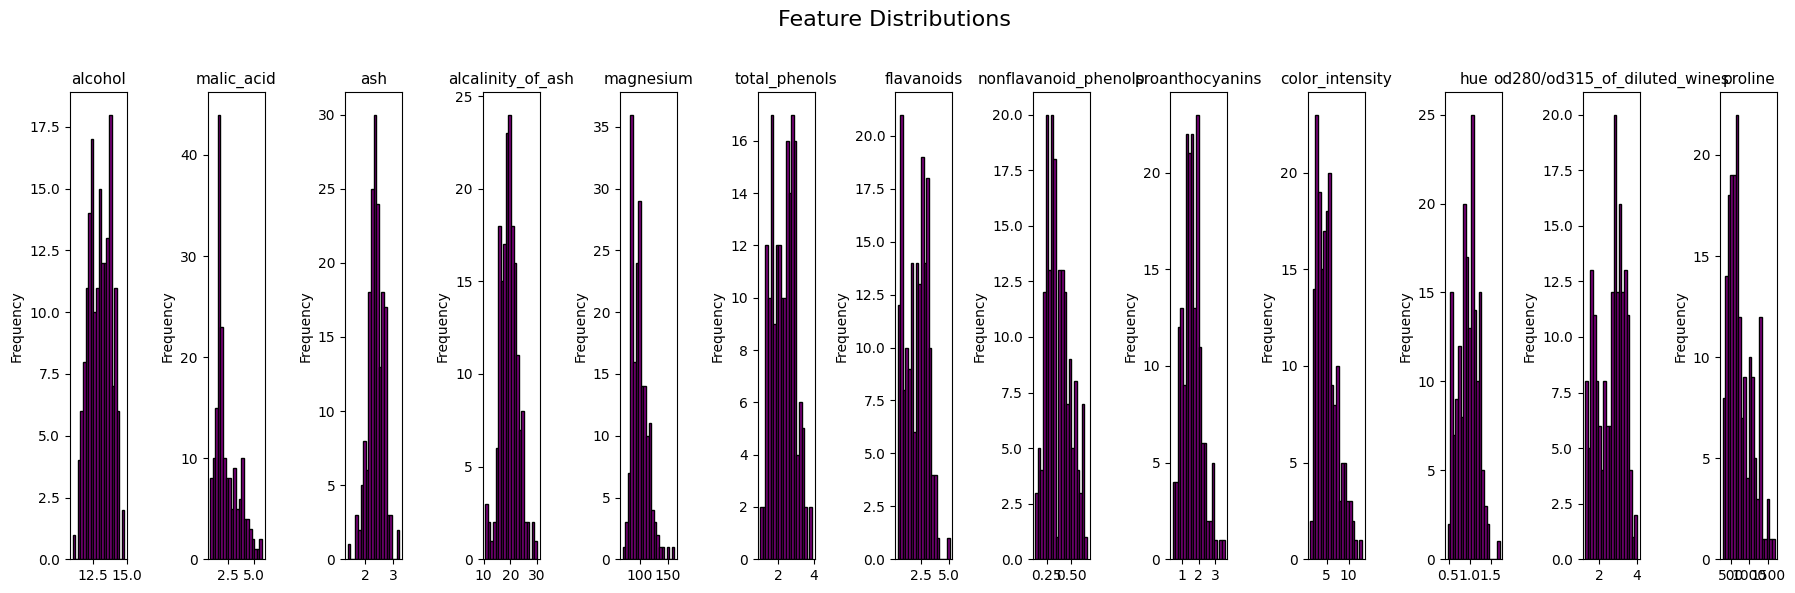

In [14]:
plot_histograms(df, features)

**Osservazioni:**
- `proline`, `alcohol` e `flavanoids` mostrano distribuzioni multimodali: questo suggerisce che le diverse classi abbiano valori medi diversi per queste feature, rendendole potenzialmente discriminanti.
- Alcune feature come `nonflavanoid_phenols` e `ash` hanno distribuzioni quasi gaussiane, meno discriminanti.
- La scala molto diversa tra feature conferma la necessità di standardizzare prima del training.

## Exploratory Data Analysis — Analisi Bivariata

I **boxplot** per classe ci permettono di identificare rapidamente quali feature sono più discriminanti tra i 3 cultivar. Una feature è discriminante se i boxplot delle 3 classi sono ben separati (poco overlap).

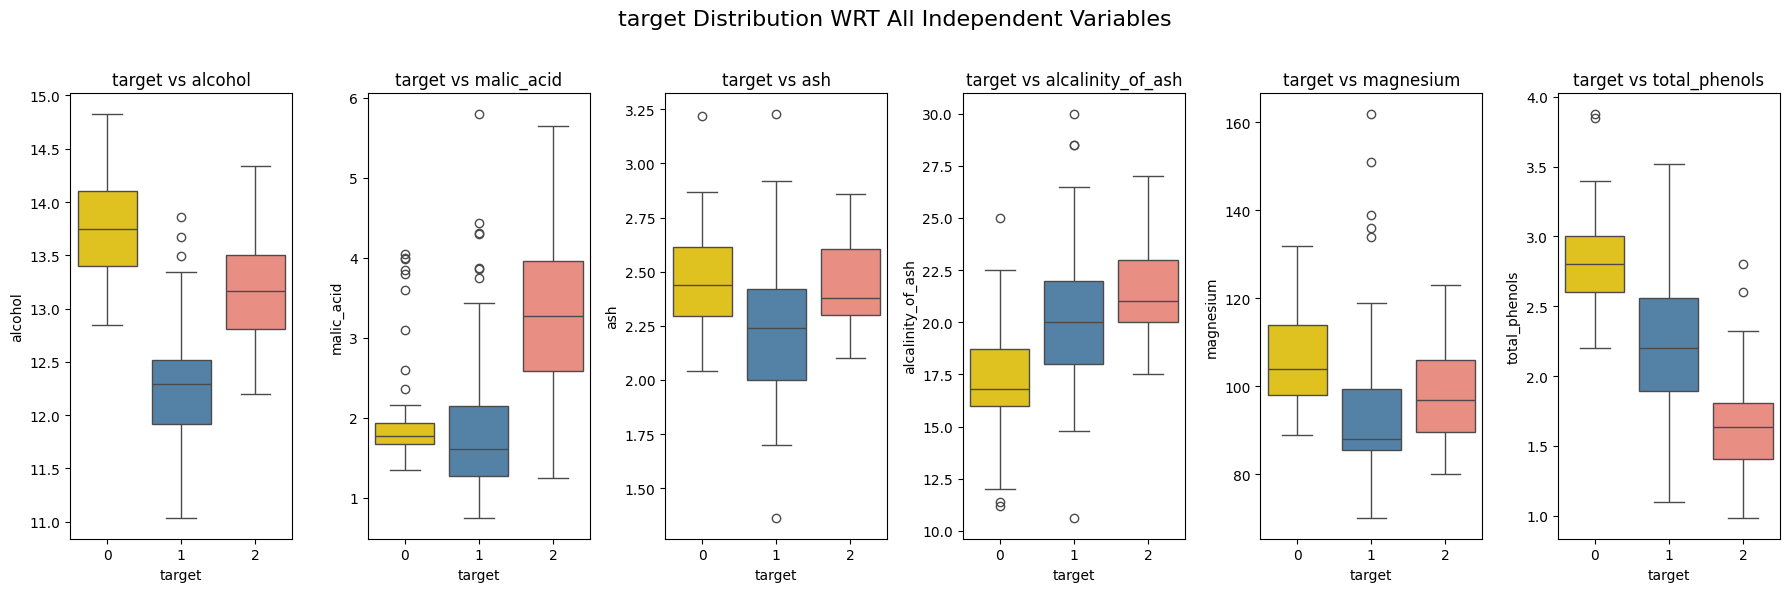

In [15]:
plot_boxplots(df, features[:6], target=target, palette=('gold', 'steelblue', 'salmon'))

**Osservazioni sulla separabilità:**
- `flavanoids`: le 3 classi sono ben separate. La classe 0 ha valori molto più alti (cultivar ricco di flavonoidi).
- `alcohol`: classe 0 ha alcol più alto, classe 1 intermedio, classe 2 più basso.
- `total_phenols`: simile a flavanoids, buona separazione.
- `malic_acid` e `alcalinity_of_ash` mostrano separazione moderata.
- `ash` è la meno discriminante tra le 6 visualizzate.

## Exploratory Data Analysis — Analisi Multivariata

Il **pairplot con correlazione** mostra le relazioni tra le feature più discriminanti, colorate per classe. Questo permette di valutare la **separabilità lineare** delle classi nello spazio 2D delle feature più importanti.

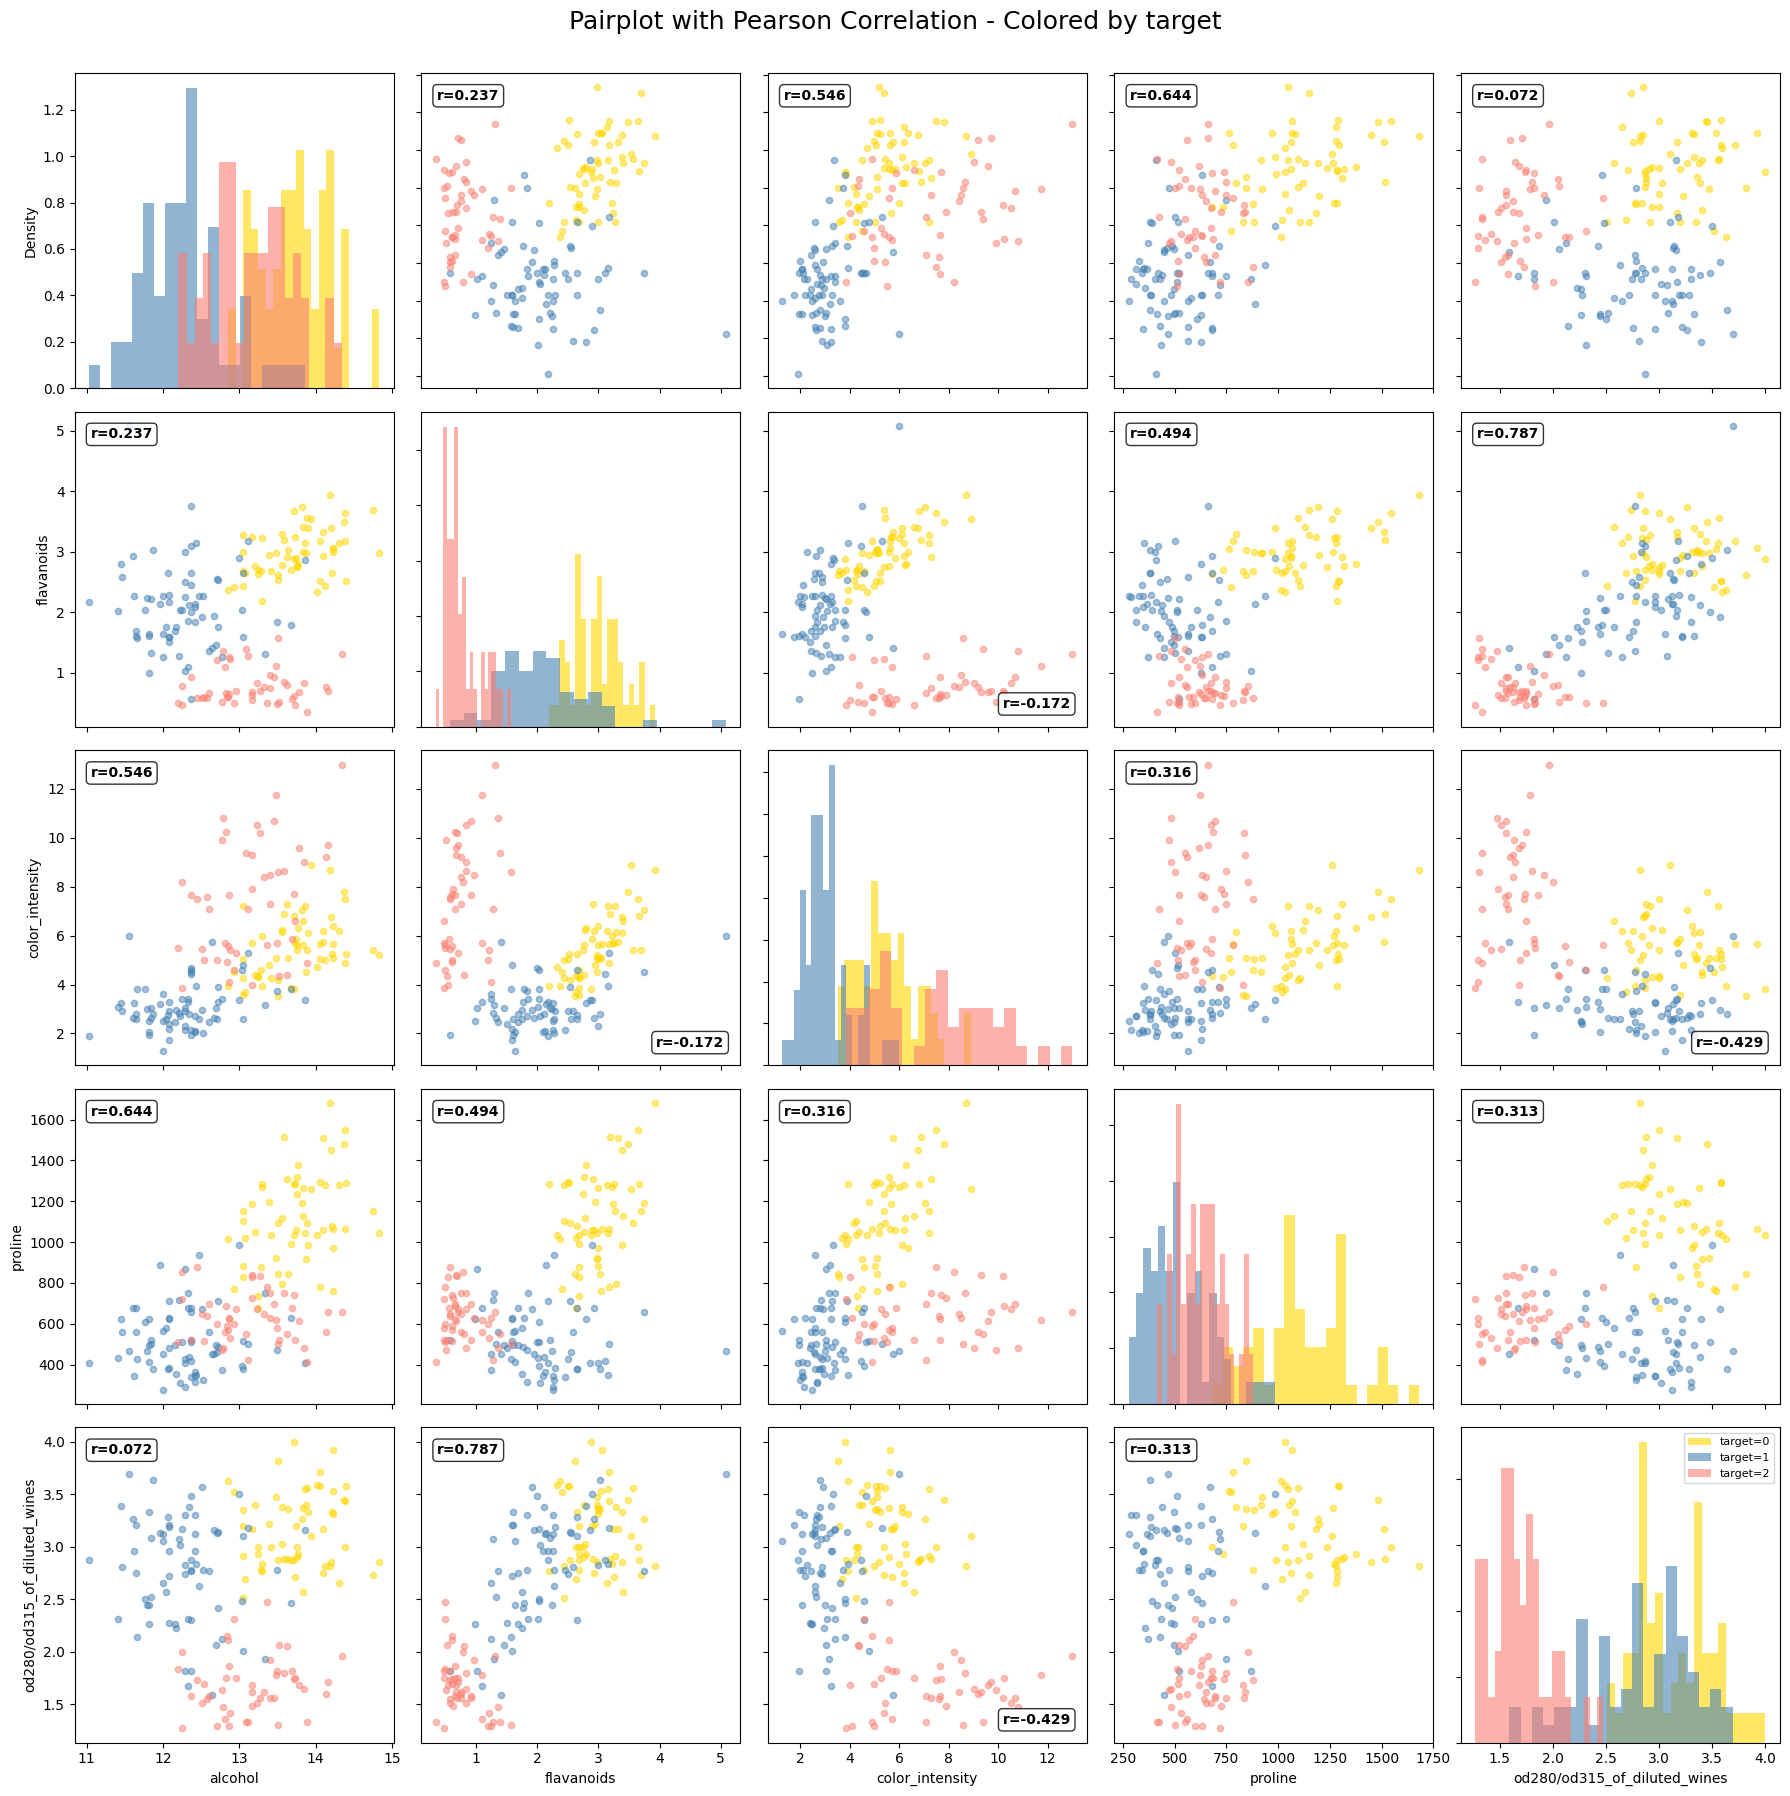

In [16]:
plot_pairplot_with_correlation(
    df,
    ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines'],
    target=target,
    palette=('gold', 'steelblue', 'salmon')
)

**Osservazioni:**
- Le 3 classi sono **linearmente separabili** nella maggior parte delle proiezioni 2D (basso overlap).
- `flavanoids` vs `proline`: separazione eccellente tra tutte e 3 le classi.
- `alcohol` vs `flavanoids`: le classi 0 e 2 si distinguono bene, la 1 è intermedia.
- La correlazione tra `flavanoids` e `od280/od315` è molto alta (r ≈ 0.79): ridondanza informativa.
- La forte separabilità lineare spiega perché la Logistic Regression raggiunga accuracy ~97-99%.

## Model Selection and Evaluation — Logistic Regression (Multinomiale)

Per la classificazione multiclasse, la Logistic Regression usa la funzione **softmax** invece della sigmoide:
$$P(y=k | \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x}}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x}}}$$

Impostiamo `multi_class='multinomial'` e `solver='lbfgs'` (ottimizzatore quasi-Newton efficiente per problemi multiclasse con pochi campioni).

Griglia di iperparametri:
- `C`: inverso della regolarizzazione (C grande = meno regolarizzazione)
- `penalty`: `'l2'` (ridge) o `None` (nessuna regolarizzazione)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[features].values
y = df[target].values

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(multi_class='multinomial', max_iter=1000, solver='lbfgs'))
])
param_grid_lr = {
    'clf__C':       [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l2', None]
}
results = nestedKFolfCV(
    X=X, y=y, pipe=pipe_lr,
    param_grid=param_grid_lr,
    scoring='accuracy',
    inner_cv=5, outer_cv=5, random_state=42
)

NESTED CROSS-VALIDATION - DETAILED RESULTS

FOLD 1:
  Best params            : {'clf__C': 1, 'clf__penalty': 'l2'}
  Best CV score (inner)  [ACCURACY]: 0.9724
  Train score   (outer)  [ACCURACY]: 1.0000
  Test score    (outer)  [ACCURACY]: 1.0000
  Train size: 142, Test size: 36

FOLD 2:
  Best params            : {'clf__C': 1, 'clf__penalty': 'l2'}
  Best CV score (inner)  [ACCURACY]: 0.9862
  Train score   (outer)  [ACCURACY]: 1.0000
  Test score    (outer)  [ACCURACY]: 0.9722
  Train size: 142, Test size: 36

FOLD 3:
  Best params            : {'clf__C': 0.1, 'clf__penalty': 'l2'}
  Best CV score (inner)  [ACCURACY]: 0.9931
  Train score   (outer)  [ACCURACY]: 0.9930
  Test score    (outer)  [ACCURACY]: 1.0000
  Train size: 142, Test size: 36

FOLD 4:
  Best params            : {'clf__C': 0.1, 'clf__penalty': 'l2'}
  Best CV score (inner)  [ACCURACY]: 0.9860
  Train score   (outer)  [ACCURACY]: 1.0000
  Test score    (outer)  [ACCURACY]: 0.9714
  Train size: 143, Test size: 35

FOLD

**Commento ai risultati:**

La Logistic Regression multinomiale ottiene accuracy ≈ 97-99% con outer CV. Questo conferma la buona **separabilità lineare** delle 3 classi nel dataset Wine.

Il ciclo interno seleziona tipicamente `C` intermedi o alti (poca regolarizzazione necessaria), a conferma che il dataset è abbastanza grande rispetto alla complessità del modello lineare con 13 feature.

---

## Bias-Variance Tradeoff

Applichiamo il bias-variance tradeoff con un **MLP Classificatore** a 3 classi di output. Il parametro `n_classes=3` nel calcolo dei parametri riflette l'output layer a 3 neuroni (uno per classe, attivazione softmax).

In [18]:
from sklearn.neural_network import MLPClassifier

depth_list     = [1, 2, 3, 4]
n_units_list   = [4, 8, 16, 32, 64, 128]
n_features_mlp = len(features)
n_classes      = 3

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(max_iter=500, random_state=42))
])

bv_results = nested_cv_bias_variance(
    X=X, y=y, pipe=pipe_mlp,
    depth_list=depth_list, n_units_list=n_units_list,
    n_features=n_features_mlp,
    n_classes=n_classes,
    scoring='accuracy',
    inner_cv=5, outer_cv=5, random_state=42,
    hls_param='clf__hidden_layer_sizes'
)

complexity_df = bv_results['complexity_df']
complexity_df[['depth', 'n_units', 'n_params', 'mean_train_acc', 'mean_val_acc']]

NESTED CROSS-VALIDATION — BIAS-VARIANCE TRADEOFF (MLP)



FOLD 1:
  Best hidden_layer_sizes : (32,)
  Best CV score (inner)   [ACCURACY]: 0.9862
  Test score    (outer)   [ACCURACY]: 1.0000

FOLD 2:
  Best hidden_layer_sizes : (128, 128)
  Best CV score (inner)   [ACCURACY]: 0.9793
  Test score    (outer)   [ACCURACY]: 1.0000

FOLD 3:
  Best hidden_layer_sizes : (64, 64, 64, 64)
  Best CV score (inner)   [ACCURACY]: 0.9862
  Test score    (outer)   [ACCURACY]: 0.9444

FOLD 4:
  Best hidden_layer_sizes : (128, 128)
  Best CV score (inner)   [ACCURACY]: 0.9931
  Test score    (outer)   [ACCURACY]: 0.9429

FOLD 5:
  Best hidden_layer_sizes : (32,)
  Best CV score (inner)   [ACCURACY]: 0.9862
  Test score    (outer)   [ACCURACY]: 1.0000

RISULTATI FINALI
Outer CV scores [ACCURACY]: ['1.0000', '1.0000', '0.9444', '0.9429', '1.0000']
Mean score [ACCURACY]: 0.9775 (+/- 0.0276)


,depth,n_units,n_params,mean_train_acc,mean_val_acc
0,1,4,71,0.970513,0.925714
1,2,4,91,0.983868,0.936995
2,3,4,111,0.992985,0.956897
3,4,4,131,0.989141,0.937094
4,1,8,139,0.987042,0.909951
5,2,8,211,1.000000,0.974877
6,1,16,275,1.000000,0.953842
7,3,8,283,0.995796,0.959507
8,4,8,355,1.000000,0.965369
9,1,32,547,1.000000,0.981970


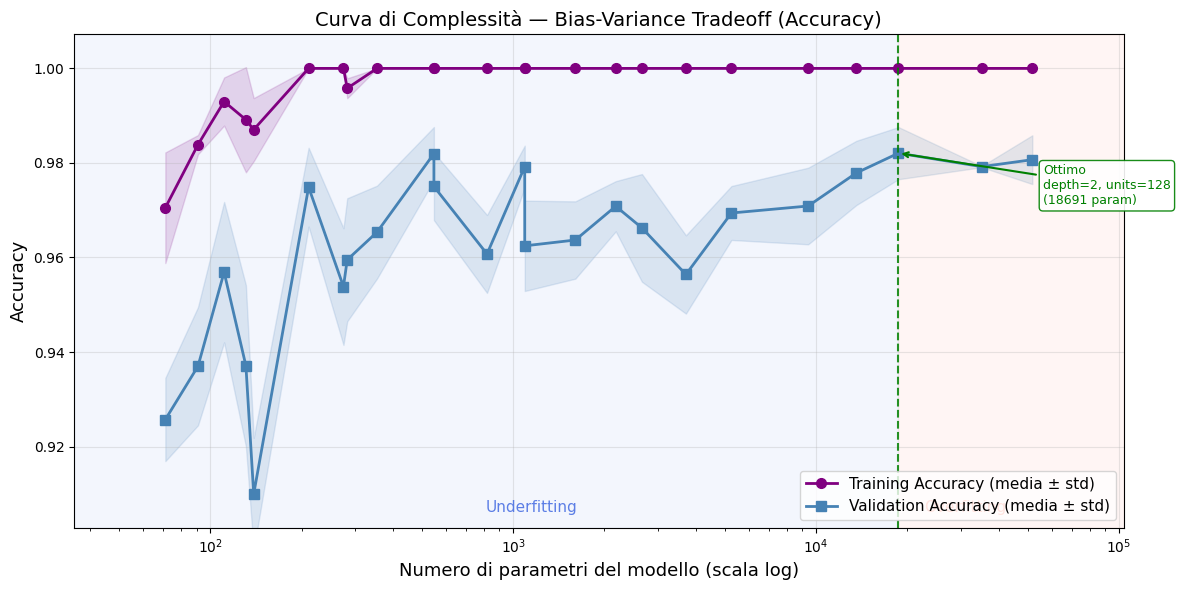

In [19]:
plot_complexity_curve(complexity_df, metrica_label='Accuracy', higher_is_better=True)

**Interpretazione della curva di complessità:**

- **Underfitting (sinistra)**: i modelli con pochi parametri (es. depth=1, 4 neuroni) possono avere accuracy inferiore, anche se su questo dataset quasi tutti i modelli raggiungono alta accuracy per la forte separabilità lineare.
- **Zona ottimale**: massimo della validation accuracy.
- **Overfitting (destra)**: i modelli molto profondi potrebbero mostrare training accuracy = 1.0 ma validation leggermente inferiore, specialmente con 178 campioni relativamente pochi.

Con dataset piccoli come Wine, il confine tra zona ottimale e overfitting è meno netto.

In [20]:
# Stima di generalizzazione finale
print("=" * 65)
print("STIMA DI GENERALIZZAZIONE — MLP ottimale (ciclo esterno)")
print("=" * 65)

for k, (score, params) in enumerate(
        zip(bv_results['outer_scores'], bv_results['best_params_per_fold']), 1):
    hls       = params['clf__hidden_layer_sizes']
    depth_k   = len(hls)
    n_units_k = hls[0]
    n_par_k   = count_mlp_params(depth_k, n_units_k, n_features_mlp, n_classes)
    print(f"Fold {k}: depth={depth_k}, units={n_units_k:3d} "
          f"({n_par_k:5d} param)  ->  accuracy = {score:.4f}")

print(f"\nMean accuracy (MLP) : {bv_results['mean_score']:.4f} +/- {bv_results['std_score']:.4f}")
print(f"Mean accuracy (LR)  : {results['mean_score']:.4f} +/- {results['std_score']:.4f}")

STIMA DI GENERALIZZAZIONE — MLP ottimale (ciclo esterno)
Fold 1: depth=1, units= 32 (  547 param)  ->  accuracy = 1.0000
Fold 2: depth=2, units=128 (18691 param)  ->  accuracy = 1.0000
Fold 3: depth=4, units= 64 (13571 param)  ->  accuracy = 0.9444
Fold 4: depth=2, units=128 (18691 param)  ->  accuracy = 0.9429
Fold 5: depth=1, units= 32 (  547 param)  ->  accuracy = 1.0000

Mean accuracy (MLP) : 0.9775 +/- 0.0276
Mean accuracy (LR)  : 0.9830 +/- 0.0139


## Conclusioni

1. **Dataset linearmente separabile**: le 3 classi di vino sono ben separabili nello spazio delle feature chimiche. La Logistic Regression multinomiale raggiunge accuracy ~97-99%.

2. **L'MLP multiclasse** usa un output layer con 3 neuroni (softmax). Il parametro `n_classes=3` entra nel conteggio dei parametri: modelli identici in depth/units hanno più parametri rispetto al caso binario.

3. **Con dataset piccoli** (178 campioni), la nested CV con 5 fold esterni usa ~142 campioni per il training, il che limita l'overfitting severo anche per MLP complessi. La curva di complessità potrebbe essere relativamente piatta nella zona ottimale-overfitting.

4. **Fix importante in utils_esercizi.py**: la funzione `plot_pairplot_with_correlation` è stata aggiornata per supportare >2 classi (palette a 3 colori). Il parametro `palette=('gold','steelblue','salmon')` va sempre specificato per 3 classi.

**Estensioni possibili**: provare `SVM` con kernel RBF, applicare PCA e visualizzare in 2D, confrontare con `RandomForestClassifier`.